# The Influence of Degrees on Post College Earnings

## Adding in the first data set from the College Scorecard site. The first data frame I created tracks institutional data.

### The datasets were too large to be loaded individually so they had to be separated into smaller files. I utilized Claude AI to divide up the the initial file into multiple files since this was a repetitive task.  I then used the glob library and a function to concatenate them back together. 

In [121]:
## importing python libraries for this project
import pandas as pd
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
import os


### Most Recent Cohorts By Institution
- **Source:** U.S. Department of Education — College Scorecard
- **Link:** https://collegescorecard.ed.gov/data/

In [122]:
df_inst = pd.concat([pd.read_csv(f) for f in sorted(glob.glob('../data/inst_part*.csv'))])

C:\Users\chris\AppData\Local\Temp\ipykernel_7636\1028643943.py:1: DtypeWarning: Columns (0: C150_L4_POOLED_SUPP, 1: C150_4_POOLED_SUPP, 2: C200_L4_POOLED_SUPP, 3: TRANS_4_POOLED_SUPP, 4: TRANS_L4_POOLED_SUPP, 5: C100_4_POOLED_SUPP, 6: C100_L4_POOLED_SUPP, 7: OMAWDP6_FTFT_POOLED_SUPP, 8: OMAWDP8_FTFT_POOLED_SUPP, 9: OMENRYP8_FTFT_POOLED_SUPP, 10: OMENRAP8_FTFT_POOLED_SUPP, 11: OMENRUP8_FTFT_POOLED_SUPP, 12: OMAWDP6_FTNFT_POOLED_SUPP, 13: OMAWDP8_FTNFT_POOLED_SUPP, 14: OMENRYP8_FTNFT_POOLED_SUPP, 15: OMENRAP8_FTNFT_POOLED_SUPP, 16: OMENRUP8_FTNFT_POOLED_SUPP, 17: CIPTITLE5, 18: CIPTITLE6, 19: OMENRYP_ALL_POOLED_SUPP, 20: OMENRAP_ALL_POOLED_SUPP, 21: OMAWDP8_ALL_POOLED_SUPP, 22: OMENRUP_ALL_POOLED_SUPP, 23: OMENRYP_FIRSTTIME_POOLED_SUPP, 24: OMENRAP_FIRSTTIME_POOLED_SUPP, 25: OMAWDP8_FIRSTTIME_POOLED_SUPP, 26: OMENRUP_FIRSTTIME_POOLED_SUPP, 27: OMENRYP_NOTFIRSTTIME_POOLED_SUPP, 28: OMENRAP_NOTFIRSTTIME_POOLED_SUPP, 29: OMAWDP8_NOTFIRSTTIME_POOLED_SUPP, 30: OMENRUP_NOTFIRSTTIME_POOLED_SUPP

### Starting the data analysis for the institutional dataset

In [123]:
df_inst.head()

,UNITID,OPEID,OPEID6,INSTNM,CITY,STABBR,ZIP,ACCREDAGENCY,INSTURL,NPCURL,...,MD_EARN_WNE_INC1_P11,MD_EARN_WNE_INC2_P11,MD_EARN_WNE_INC3_P11,MD_EARN_WNE_INDEP0_P11,MD_EARN_WNE_INDEP1_P11,MD_EARN_WNE_MALE0_P11,MD_EARN_WNE_MALE1_P11,SCORECARD_SECTOR,EARN_THR_STATE,EARN_THR_NAT
0,100654,100200.0,1002.0,Alabama A & M University,Normal,AL,35762,Southern Association of Colleges and Schools C...,www.aamu.edu/,www.aamu.edu/admissions-aid/tuition-fees/net-p...,...,36650.0,41070.0,47016.0,38892.0,41738.0,38167.0,40250.0,4,30168.0,32842
1,100663,105200.0,1052.0,University of Alabama at Birmingham,Birmingham,AL,35294-0110,Southern Association of Colleges and Schools C...,https://www.uab.edu/,https://tcc.ruffalonl.com/University of Alabam...,...,47182.0,51896.0,54368.0,50488.0,51505.0,46559.0,59181.0,4,30168.0,32842
2,100690,2503400.0,25034.0,Amridge University,Montgomery,AL,36117-3553,Southern Association of Colleges and Schools C...,https://www.amridgeuniversity.edu/,https://www2.amridgeuniversity.edu:9091/,...,35752.0,41007.0,NaN,NaN,38467.0,32654.0,49435.0,5,30168.0,32842
3,100706,105500.0,1055.0,University of Alabama in Huntsville,Huntsville,AL,35899,Southern Association of Colleges and Schools C...,www.uah.edu/,uah.clearcostcalculator.com/student/default/ne...,...,51208.0,62219.0,62577.0,55920.0,60221.0,47787.0,67454.0,4,30168.0,32842
4,100724,100500.0,1005.0,Alabama State University,Montgomery,AL,36104-0271,Southern Association of Colleges and Schools C...,www.alasu.edu/,tcc.ruffalonl.com/Alabama State University/Fre...,...,32844.0,36932.0,37966.0,34294.0,31797.0,32303.0,36964.0,4,30168.0,32842


In [124]:
df_inst.info()

<class 'pandas.DataFrame'>
Index: 6322 entries, 0 to 3160
Columns: 3308 entries, UNITID to EARN_THR_NAT
dtypes: float64(933), int64(15), object(97), str(2263)
memory usage: 159.6+ MB


### Checking for duplicate records. There are none

In [125]:
print(df_inst.duplicated().sum())

0


### Checking for null records and can see several columns have nulls

In [126]:
print(df_inst.isnull().sum())

UNITID                      0
OPEID                      27
OPEID6                     27
INSTNM                      0
CITY                        0
                         ... 
MD_EARN_WNE_MALE0_P11    1587
MD_EARN_WNE_MALE1_P11    2177
SCORECARD_SECTOR            0
EARN_THR_STATE             11
EARN_THR_NAT                0
Length: 3308, dtype: int64


### Filling Na with Spaces instead

In [127]:
df = df_inst.fillna("")

### Checking for Na again and they are gone

In [128]:
print(df_inst.isna().sum())

UNITID                      0
OPEID                      27
OPEID6                     27
INSTNM                      0
CITY                        0
                         ... 
MD_EARN_WNE_MALE0_P11    1587
MD_EARN_WNE_MALE1_P11    2177
SCORECARD_SECTOR            0
EARN_THR_STATE             11
EARN_THR_NAT                0
Length: 3308, dtype: int64


### Created a python dictionary with the help of Claude AI

In [129]:
INST_COLUMNS = {
    'UNITID':          'school_id',
    'INSTNM':          'school_name',
    'STABBR':          'state',
    'REGION':          'region_code',
    'CONTROL':         'control_type',
    'PREDDEG':         'predominant_degree',
    'LOCALE':          'locale_type',
    'UGDS':            'undergrad_enrollment',
    'UGDS_MEN':        'undergrad_men',
    'UGDS_WOMEN':      'undergrad_women',
    'PCTPELL':         'pct_pell_recipients',
    'FAMINC':          'median_family_income',
    'TUITIONFEE_IN':   'tuition_in_state',
    'TUITIONFEE_OUT':  'tuition_out_of_state',
    'NPT4_PUB':        'net_price_titleiv_public',
    'NPT4_PRIV':       'net_price_titleiv_private',
    'COSTT4_A':        'avg_total_cost',
    'C150_4':          'completion_rate_150pct_4yr',
    'MD_EARN_WNE_P6':  'median_earn_wne_6yr',
    'MD_EARN_WNE_P10': 'median_earn_wne_10yr',
    'DEBT_MDN':        'median_debt_stafford_grad_plus',
}

### Assigns the 21 values I am using for my database to the dataframe and renames them logical names 

In [130]:
df_inst = df_inst[list(INST_COLUMNS.keys())].rename(columns=INST_COLUMNS)
print(df_inst.shape)

(6322, 21)


### Looking for correlation in values in the institution data frame based on the 21 columns loaded. After viewing the chart I can see that cost and earnings have a correlation around 50 to 60 %. Pell grant students correlate negatively with tuition probably indicating that lower income students might earn less??

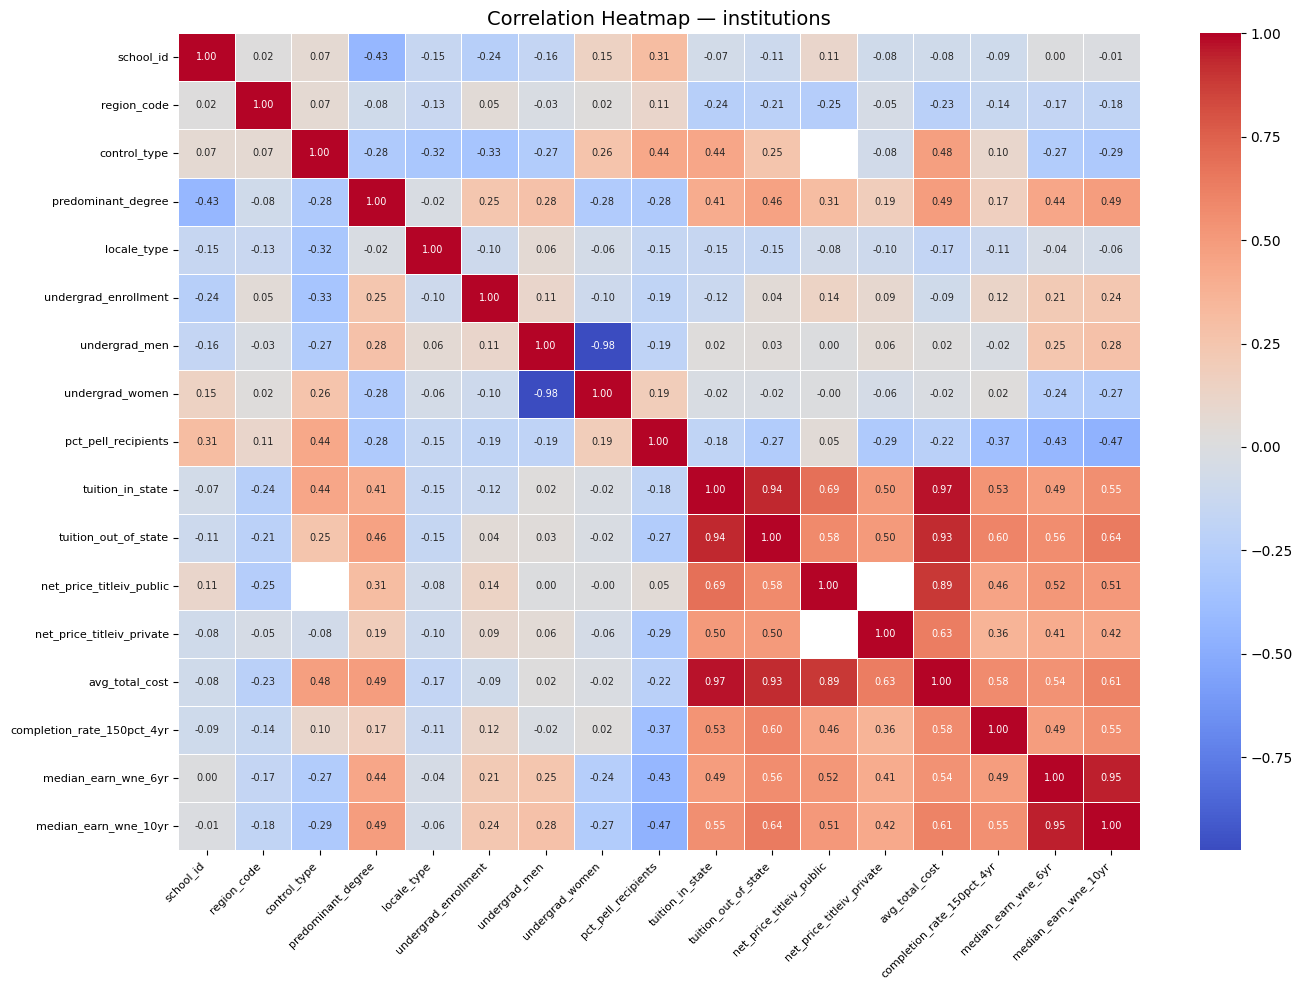

In [131]:


numeric_df = df_inst.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 7}
)

plt.title('Correlation Heatmap — institutions', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Update "PS", "NULL", "NaN", "N/A", "" to NaN which works better in Python

In [132]:

missing_values = ["PS", "NULL", "NaN", "N/A", ""]
df_inst = df_inst.replace(missing_values, np.nan)

### Review the first 4 rows to make sure the data is clean and looks the way I expected

In [133]:
df_inst.head()

,school_id,school_name,state,region_code,control_type,predominant_degree,locale_type,undergrad_enrollment,undergrad_men,undergrad_women,...,median_family_income,tuition_in_state,tuition_out_of_state,net_price_titleiv_public,net_price_titleiv_private,avg_total_cost,completion_rate_150pct_4yr,median_earn_wne_6yr,median_earn_wne_10yr,median_debt_stafford_grad_plus
0,100654,Alabama A & M University,AL,5,1,3,12.0,6124.0,0.4221,0.5779,...,32362.826114,10024.0,18634.0,17621.0,NaN,27153.0,0.2403,27851.0,40628.0,16600
1,100663,University of Alabama at Birmingham,AL,5,1,3,12.0,11635.0,0.3680,0.6320,...,51306.674306,9098.0,22562.0,18749.0,NaN,28145.0,0.6423,46572.0,54501.0,15832
2,100690,Amridge University,AL,5,2,3,12.0,241.0,0.3444,0.6556,...,21079.472973,7590.0,7590.0,NaN,NaN,NaN,1.0000,30377.0,37621.0,13385
3,100706,University of Alabama in Huntsville,AL,5,1,3,12.0,6591.0,0.6095,0.3905,...,61096.588949,12132.0,26408.0,18796.0,NaN,27392.0,0.6429,55610.0,61767.0,13905
4,100724,Alabama State University,AL,5,1,3,12.0,3477.0,0.3653,0.6347,...,31684.382188,11248.0,19576.0,20435.0,NaN,23586.0,0.3034,27453.0,34502.0,17500


### Updating null values to None because this is easier for SQL to ingest

In [134]:

df_inst = df_inst.replace(["PS", "NULL", "NA", "N/A", ""], np.nan)
df_inst = df_inst.where(pd.notnull(df_inst), None)

print(df_inst.head())

   school_id                          school_name state  region_code  \
0     100654             Alabama A & M University    AL            5   
1     100663  University of Alabama at Birmingham    AL            5   
2     100690                   Amridge University    AL            5   
3     100706  University of Alabama in Huntsville    AL            5   
4     100724             Alabama State University    AL            5   

   control_type  predominant_degree  locale_type  undergrad_enrollment  \
0             1                   3         12.0                6124.0   
1             1                   3         12.0               11635.0   
2             2                   3         12.0                 241.0   
3             1                   3         12.0                6591.0   
4             1                   3         12.0                3477.0   

   undergrad_men  undergrad_women  ...  median_family_income tuition_in_state  \
0         0.4221           0.5779  ...   

In [135]:
df_inst.head()

,school_id,school_name,state,region_code,control_type,predominant_degree,locale_type,undergrad_enrollment,undergrad_men,undergrad_women,...,median_family_income,tuition_in_state,tuition_out_of_state,net_price_titleiv_public,net_price_titleiv_private,avg_total_cost,completion_rate_150pct_4yr,median_earn_wne_6yr,median_earn_wne_10yr,median_debt_stafford_grad_plus
0,100654,Alabama A & M University,AL,5,1,3,12.0,6124.0,0.4221,0.5779,...,32362.826114,10024.0,18634.0,17621.0,NaN,27153.0,0.2403,27851.0,40628.0,16600
1,100663,University of Alabama at Birmingham,AL,5,1,3,12.0,11635.0,0.3680,0.6320,...,51306.674306,9098.0,22562.0,18749.0,NaN,28145.0,0.6423,46572.0,54501.0,15832
2,100690,Amridge University,AL,5,2,3,12.0,241.0,0.3444,0.6556,...,21079.472973,7590.0,7590.0,NaN,NaN,NaN,1.0000,30377.0,37621.0,13385
3,100706,University of Alabama in Huntsville,AL,5,1,3,12.0,6591.0,0.6095,0.3905,...,61096.588949,12132.0,26408.0,18796.0,NaN,27392.0,0.6429,55610.0,61767.0,13905
4,100724,Alabama State University,AL,5,1,3,12.0,3477.0,0.3653,0.6347,...,31684.382188,11248.0,19576.0,20435.0,NaN,23586.0,0.3034,27453.0,34502.0,17500


### Ingesting the data for the programs data frame.  I utilized Claude AI to divide up the the initial file into multiple files since this was a repetitive task. I then used the glob library and a function to concatenate them back together. 

### Most Recent Cohorts By Field of Study
- **Source:** U.S. Department of Education — College Scorecard
- **Link:** https://collegescorecard.ed.gov/data/

In [136]:

df_programs = pd.concat([pd.read_csv(f) for f in sorted(glob.glob('../data/fos_part*.csv'))])

### Taking a look at the programs data

In [137]:
df_programs.info()

<class 'pandas.DataFrame'>
Index: 227980 entries, 0 to 67979
Columns: 178 entries, UNITID to EARN_P75_4YR_NAT
dtypes: float64(3), int64(5), str(170)
memory usage: 311.3 MB


In [138]:
df_programs.head()

,UNITID,OPEID6,INSTNM,CONTROL,MAIN,CIPCODE,CIPDESC,CREDLEV,CREDDESC,IPEDSCOUNT1,...,EARN_COUNT_MALE_WNE_5YR,EARN_MALE_WNE_MDN_5YR,EARN_COUNT_NOMALE_WNE_5YR,EARN_NOMALE_WNE_MDN_5YR,EARN_COUNT_HIGH_CRED_5YR,EARN_IN_STATE_5YR,EARN_COUNT_WNE_4YR_NAT,EARN_MDN_4YR_NAT,EARN_P25_4YR_NAT,EARN_P75_4YR_NAT
0,100654.0,1002,Alabama A & M University,Public,1,109,Animal Sciences.,3,Bachelor's Degree,9.0,...,PS,PS,PS,PS,PS,PS,6104,49634,36349,66880
1,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,3,Bachelor's Degree,7.0,...,PS,PS,PS,PS,PS,PS,1301,70873,54113,88238
2,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,5,Master's Degree,7.0,...,PS,PS,PS,PS,PS,PS,380,88332,65085,115796
3,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,6,Doctoral Degree,3.0,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS
4,100654.0,1002,Alabama A & M University,Public,1,199,Agricultural/Animal/Plant/Veterinary Science a...,3,Bachelor's Degree,1.0,...,PS,PS,PS,PS,PS,PS,413,65543,46023,83774


## Checking for null and duplicated data

In [139]:
print(df_programs.duplicated().sum())

0


In [140]:
print(df_programs.isnull().sum())

UNITID                     7020
OPEID6                        0
INSTNM                        0
CONTROL                       0
MAIN                          0
                          ...  
EARN_IN_STATE_5YR         19411
EARN_COUNT_WNE_4YR_NAT        0
EARN_MDN_4YR_NAT              0
EARN_P25_4YR_NAT              0
EARN_P75_4YR_NAT              0
Length: 178, dtype: int64


### Update "PS", "NULL", "NaN", "N/A", "" to NaN which works better in Python

In [141]:

missing_values = ["PS", "NULL", "NaN", "N/A", ""]
df_programs = df_programs.replace(missing_values, np.nan)

### Used Claude AI to rename column names from the dataset to logical names and create a data dictionary

In [142]:
PROGRAM_COLUMNS = {
    'UNITID':                    'school_id',
    'CIPCODE':                   'cip_code',
    'CIPDESC':                   'program_name',
    'CREDLEV':                   'cred_level',
    'CREDDESC':                  'cred_label',
    'DEBT_ALL_STGP_ANY_MDN':     'median_debt_stafford_grad_plus',
    'DEBT_MALE_STGP_ANY_MDN':    'median_debt_male_stafford_grad_plus',
    'DEBT_NOTMALE_STGP_ANY_MDN': 'median_debt_female_stafford_grad_plus',
    'EARN_MDN_1YR':              'median_earn_wne_1yr',
    'EARN_MDN_4YR':              'median_earn_wne_4yr',
    'EARN_MDN_5YR':              'median_earn_wne_5yr',
    'EARN_MALE_WNE_MDN_1YR':     'median_earn_male_wne_1yr',
    'EARN_MALE_WNE_MDN_4YR':     'median_earn_male_wne_4yr',
    'EARN_NOMALE_WNE_MDN_1YR':   'median_earn_female_wne_1yr',
    'EARN_NOMALE_WNE_MDN_4YR':   'median_earn_female_wne_4yr',
    'EARN_PELL_WNE_MDN_1YR':     'median_earn_pell_wne_1yr',
    'EARN_NOPELL_WNE_MDN_1YR':   'median_earn_nopell_wne_1yr',
    'EARN_PELL_WNE_MDN_4YR':     'median_earn_pell_wne_4yr',
    'EARN_NOPELL_WNE_MDN_4YR':   'median_earn_nopell_wne_4yr',
}

In [143]:
df_programs = df_programs[list(PROGRAM_COLUMNS.keys())].rename(columns=PROGRAM_COLUMNS)
print(df_programs.shape)

(227980, 19)


### Ingesting the data for the awards data frame. I did not need to divide this dataset into smaller sets because it was small enough to upload to github.

In [144]:
import pandas as pd
df_awards= pd.read_csv('../data/c2024_a.csv', low_memory=False)

#### Checking for nulls and duplicates

In [145]:
print(df_awards.duplicated().sum())

0


In [146]:
print(df_awards.isnull().sum())

UNITID      0
CIPCODE     0
MAJORNUM    0
AWLEVEL     0
XCTOTALT    0
           ..
CNRALT      0
XCNRALM     0
CNRALM      0
XCNRALW     0
CNRALW      0
Length: 64, dtype: int64


### Update "PS", "NULL", "NaN", "N/A", "" to NaN which works better in Python

In [147]:

missing_values = ["PS", "NULL", "NaN", "N/A", ""]
df_awards = df_awards.replace(missing_values, np.nan)

### Used Claude AI to rename column names from the dataset to logical names and create a data dictionary

In [148]:
AWARDS_COLUMNS = {
    'UNITID':   'school_id',
    'CIPCODE':  'cip_code',
    'MAJORNUM': 'major_num',
    'AWLEVEL':  'award_level',
    'CTOTALT':  'completions_total',
    'CTOTALM':  'completions_male',
    'CTOTALW':  'completions_female',
}

### C2024a
- **Source:** National Center for Education Statistics
- **Link:** https://nces.ed.gov/ipeds/datacenter/DataFiles.aspx

In [149]:
df_awards = df_awards[list(AWARDS_COLUMNS.keys())].rename(columns=AWARDS_COLUMNS)
print(df_awards.shape)

(307707, 7)


 ### drop duplicates for each key (key combo) to ensure those values are unique

In [150]:
df_inst = df_inst.drop_duplicates(subset=['school_id'])
df_programs = df_programs.drop_duplicates(subset=['school_id', 'cip_code', 'cred_level'])
df_awards = df_awards.drop_duplicates(subset=['school_id', 'cip_code', 'award_level'])

# Now that the data frames are created for institutions, programs, and awards I need to create a SQLite database and connect to it.

## Establish the database path and create the database. Print a statement that proves the connection

In [151]:
DB_PATH = os.path.join('..', 'data', 'student_performance.db')
connection = sqlite3.connect(DB_PATH)
cursor = connection.cursor()
print('Connected to:', DB_PATH)

Connected to: ..\data\student_performance.db


### Drop the tables if they already exist (in the right sequence because of FK dependency). This way the script can be re-executed even if the database was already created

In [152]:
cursor.execute('DROP TABLE IF EXISTS awards;')
cursor.execute('DROP TABLE IF EXISTS programs;')
cursor.execute('DROP TABLE IF EXISTS institutions;')
print('Existing tables dropped.')

Existing tables dropped.


### Create institutions, programs, awards tables. Used Claude AI for formatting

In [153]:
cursor.execute('''
    CREATE TABLE institutions (
        school_id                      INTEGER PRIMARY KEY,
        school_name                    TEXT,
        state                          TEXT,
        region_code                    INTEGER,
        control_type                   INTEGER,
        predominant_degree             INTEGER,
        locale_type                    INTEGER,
        undergrad_enrollment           REAL,
        undergrad_men                  REAL,
        undergrad_women                REAL,
        pct_pell_recipients            REAL,
        median_family_income           REAL,
        tuition_in_state               REAL,
        tuition_out_of_state           REAL,
        net_price_titleiv_public       REAL,
        net_price_titleiv_private      REAL,
        avg_total_cost                 REAL,
        completion_rate_150pct_4yr     REAL,
        median_earn_wne_6yr            REAL,
        median_earn_wne_10yr           REAL,
        median_debt_stafford_grad_plus REAL
    );
''')
print('institutions table created.')

institutions table created.


In [154]:
cursor.execute('''
    CREATE TABLE programs (
        program_id                            INTEGER PRIMARY KEY AUTOINCREMENT,
        school_id                             INTEGER,
        cip_code                              TEXT,
        program_name                          TEXT,
        cred_level                            INTEGER,
        cred_label                            TEXT,
        median_debt_stafford_grad_plus        REAL,
        median_debt_male_stafford_grad_plus   REAL,
        median_debt_female_stafford_grad_plus REAL,
        median_earn_wne_1yr                   REAL,
        median_earn_wne_4yr                   REAL,
        median_earn_wne_5yr                   REAL,
        median_earn_male_wne_1yr              REAL,
        median_earn_male_wne_4yr              REAL,
        median_earn_female_wne_1yr            REAL,
        median_earn_female_wne_4yr            REAL,
        median_earn_pell_wne_1yr              REAL,
        median_earn_nopell_wne_1yr            REAL,
        median_earn_pell_wne_4yr              REAL,
        median_earn_nopell_wne_4yr            REAL,
        FOREIGN KEY (school_id) REFERENCES institutions(school_id),
        UNIQUE (school_id, cip_code, cred_level)
    );
''')
print('programs table created.')

programs table created.


In [155]:
cursor.execute('''
    CREATE TABLE awards (
        award_id           INTEGER PRIMARY KEY AUTOINCREMENT,
        school_id          INTEGER,
        cip_code           TEXT,
        cred_level         INTEGER,
        award_level        INTEGER,
        completions_total  INTEGER,
        completions_male   INTEGER,
        completions_female INTEGER,
        FOREIGN KEY (school_id) REFERENCES institutions(school_id),
        UNIQUE (school_id, cip_code, award_level)
    );
''')
print('awards table created.')

awards table created.


### Append data to the data frames created above and print the number of rows added (this allows additional rows to be added without replacing). This step is repeated for the institutions, programs, and awards dataframes.

In [156]:
df_inst.to_sql('institutions', connection, if_exists='append', index=False)
print(f'institutions inserted: {len(df_inst):,} rows')

institutions inserted: 6,322 rows


In [157]:
df_programs.to_sql('programs', connection, if_exists='append', index=False)
print(f'programs inserted: {len(df_programs):,} rows')

programs inserted: 221,947 rows


In [158]:
df_awards = df_awards[df_awards['major_num'] == 1].drop(columns=['major_num'])

In [159]:
df_awards.to_sql('awards', connection, if_exists='append', index=False)
print(f'awards inserted: {len(df_awards):,} rows')

awards inserted: 286,979 rows


### Close the connection for cleanup

In [160]:
connection.close()
print('Connection closed.')

Connection closed.


### Code for connecting to the the database after its already been created

In [161]:
import sqlite3
import pandas as pd
import os

connection = sqlite3.connect('../data/student_performance.db')
cursor = connection.cursor()
print('Connected to:', '../data/student_performance.db')

Connected to: ../data/student_performance.db


### Query to test that my new database works and yay! it does

In [162]:
pd.read_sql('SELECT * FROM programs', connection)

,program_id,school_id,cip_code,program_name,cred_level,cred_label,median_debt_stafford_grad_plus,median_debt_male_stafford_grad_plus,median_debt_female_stafford_grad_plus,median_earn_wne_1yr,median_earn_wne_4yr,median_earn_wne_5yr,median_earn_male_wne_1yr,median_earn_male_wne_4yr,median_earn_female_wne_1yr,median_earn_female_wne_4yr,median_earn_pell_wne_1yr,median_earn_nopell_wne_1yr,median_earn_pell_wne_4yr,median_earn_nopell_wne_4yr
0,1,100654.0,109,Animal Sciences.,3,Bachelor's Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,100654.0,110,Food Science and Technology.,3,Bachelor's Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,100654.0,110,Food Science and Technology.,5,Master's Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,100654.0,110,Food Science and Technology.,6,Doctoral Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,100654.0,199,Agricultural/Animal/Plant/Veterinary Science a...,3,Bachelor's Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221942,221943,NaN,2401,"Liberal Arts and Sciences, General Studies and...",8,Graduate/Professional Certificate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221943,221944,NaN,4201,"Psychology, General.",8,Graduate/Professional Certificate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221944,221945,NaN,4599,"Social Sciences, Other.",8,Graduate/Professional Certificate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221945,221946,NaN,4228,"Clinical, Counseling and Applied Psychology.",7,First Professional Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### This is a SQL Query designed to show me the earnings gap between men and women by degree and then rank them to show the largest gap by degree.

In [181]:
df_ranking = pd.read_sql('''
     select *
    from (
        select program_name,
               cred_label,
               round(avg_earn_male, 0) as avg_earnings_for_a_man,
               round(avg_earn_female, 0) as avg_earnings_for_a_female,
               round(earnings_gap, 0) as earnings_gap,
               rank() over (partition by cred_level order by earnings_gap desc) as rank_within_cred_level
        from (
                select p.program_name,
                   p.cred_label,
                   p.cred_level,
                   avg(p.median_earn_male_wne_4yr) as avg_earn_male,
                   avg(p.median_earn_female_wne_4yr) as avg_earn_female,
                   avg(p.median_earn_male_wne_4yr)- avg(p.median_earn_female_wne_4yr) as earnings_gap
                from programs p
                where p.median_earn_male_wne_4yr IS NOT NULL
                and p.median_earn_female_wne_4yr IS NOT NULL
                group by p.program_name, p.cred_label, p.cred_level
        )
    )
    where rank_within_cred_level <= 6
    order by rank_within_cred_level, rank_within_cred_level
''', connection)
display(df_ranking)

,program_name,cred_label,avg_earnings_for_a_man,avg_earnings_for_a_female,earnings_gap,rank_within_cred_level
0,Natural Sciences.,Undergraduate Certificate or Diploma,58650.0,33418.0,25232.0,1
1,Physical Science Technologies/Technicians.,Associate's Degree,100461.0,47224.0,53237.0,1
2,"Engineering, General.",Bachelor's Degree,109335.0,86798.0,22537.0,1
3,Public Health.,Post-baccalaureate Certificate,91132.0,79067.0,12065.0,1
4,Real Estate.,Master's Degree,148708.0,114747.0,33961.0,1
5,Chemistry.,Doctoral Degree,117909.0,80674.0,37235.0,1
6,"Registered Nursing, Nursing Administration, Nu...",First Professional Degree,183741.0,129047.0,54695.0,1
7,Advanced/Graduate Dentistry and Oral Sciences.,Graduate/Professional Certificate,207391.0,148809.0,58582.0,1
8,"Specialized Sales, Merchandising and Marketin...",Undergraduate Certificate or Diploma,50967.0,28493.0,22474.0,2
9,Industrial Production Technologies/Technicians.,Associate's Degree,87997.0,47877.0,40120.0,2


### This bar chart is designed to show the earnings gap by degree for men and women. The top earning gaps are in dental, nursing, legal professions and chemistry. $60,000 is a staggering earnings gap for dentists.

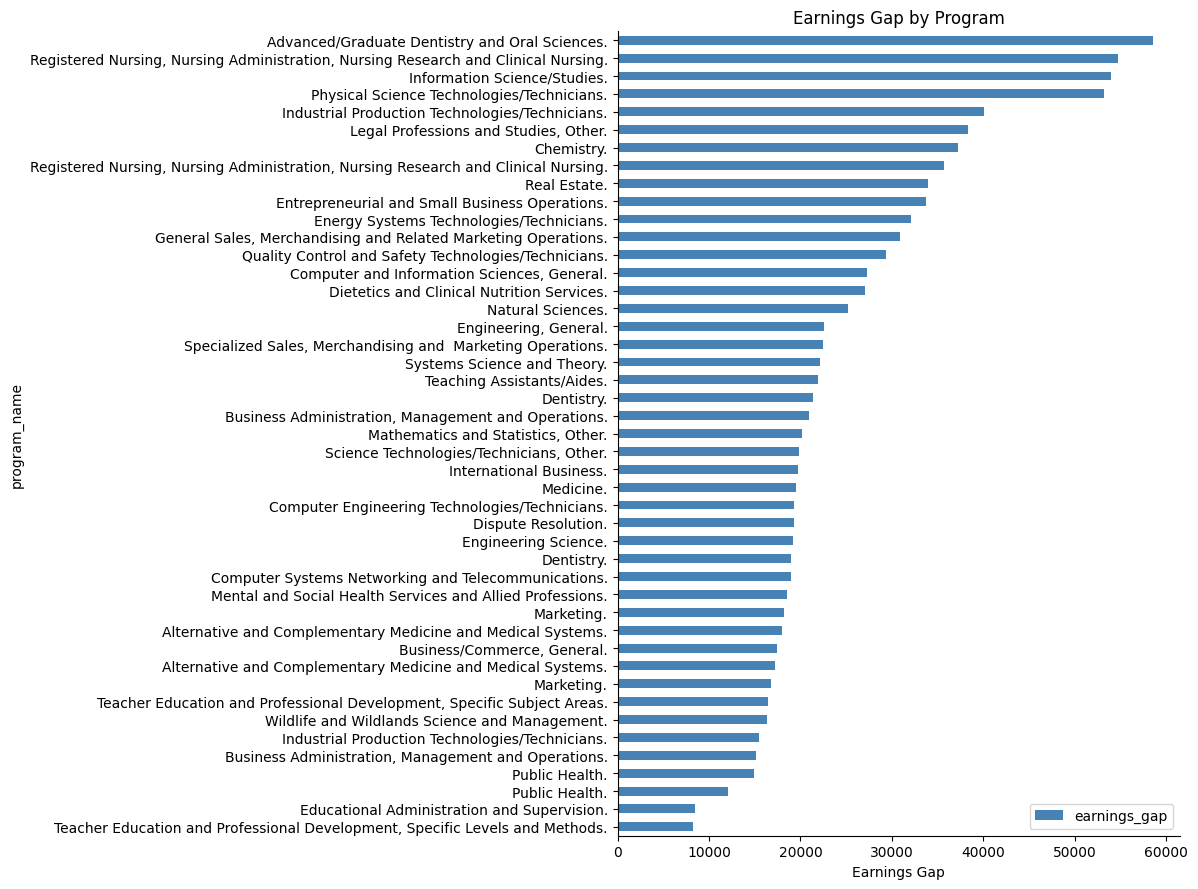

In [164]:


df_sorted = df_ranking.sort_values('earnings_gap', ascending=True)

df_sorted.plot(kind='barh', x='program_name', y='earnings_gap', figsize=(12, 9), color='steelblue')
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.title("Earnings Gap by Program")
plt.xlabel("Earnings Gap")
plt.tight_layout()
plt.show()

### This bar chart is designed to show the side by side disparity in earnings by gender and degree. The above chart aggregates the gap and the below chart breaks it down into more detail.

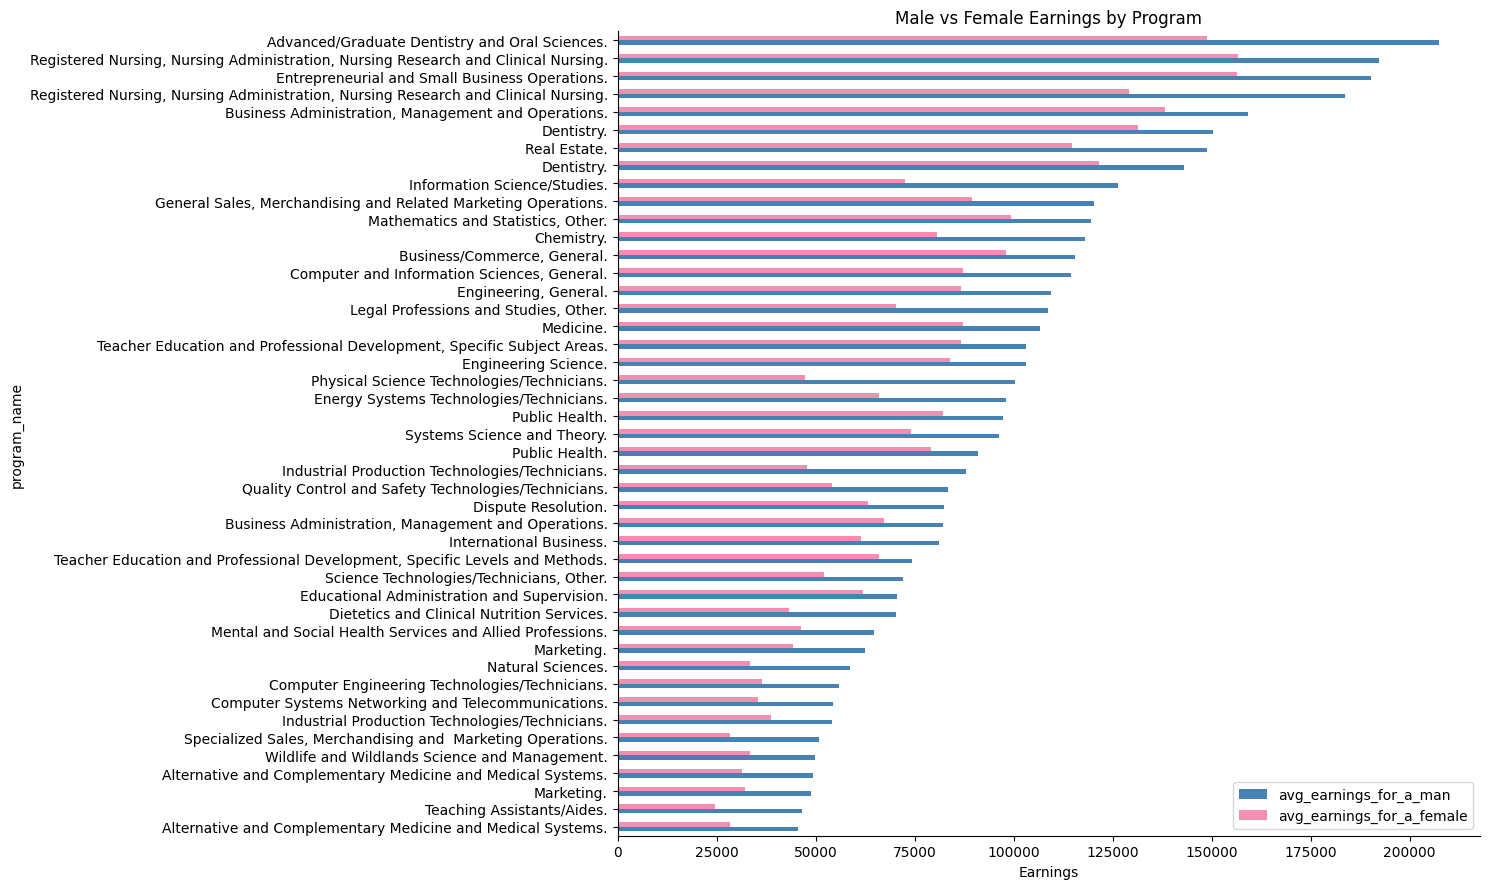

In [165]:


df_sorted = df_ranking.sort_values('avg_earnings_for_a_man', ascending=True)

df_sorted[['program_name', 'avg_earnings_for_a_man', 'avg_earnings_for_a_female']].plot( kind='barh', x='program_name', figsize=(15, 9),color=['steelblue', '#F48FB1']
)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.title("Male vs Female Earnings by Program")
plt.xlabel("Earnings")
plt.tight_layout()
plt.show()

### As part of my deep dive into College Scorecard data I am trying to figure out which type of school is the most cost effective (e.g. Public vs Private Non-Profit vs Private for Profit). The below query investigates after 5 years compare to the amount of debt accrued. I limited the row count to 25 so that I could produce a readable chart and hone in on the worst offenders.

In [166]:
df_school_debt_limit_25 = pd.read_sql('''
    select i.school_name,
           i.state,
           case i.control_type
               when 1 THEN 'Public'
               when 2 THEN 'Private Non-Profit'
               when 3 THEN 'Private For-Profit'
                end AS school_type,
           count(*) AS program_count,
           round(avg(p.median_debt_stafford_grad_plus), 0) AS avg_debt,
           round(avg(p.median_earn_wne_5yr), 0) AS avg_earn_5yr,
           round(avg(p.median_debt_stafford_grad_plus)/ avg(p.median_earn_wne_5yr), 2) AS debt_to_income_ratio
    from programs p
    join institutions i 
        on p.school_id = i.school_id
    where p.median_earn_wne_4yr is not null
            and p.median_debt_stafford_grad_plus is not null
            and p.median_earn_wne_5yr > 0
    group by 
        i.school_id
        , i.school_name
        , i.state
        , i.control_type
    order by debt_to_income_ratio DESC
    limit 25
''', connection)
display(df_school_debt_limit_25)

,school_name,state,school_type,program_count,avg_debt,avg_earn_5yr,debt_to_income_ratio
0,Cleveland Institute of Music,OH,Private Non-Profit,1,25500.0,14612.0,1.75
1,Moler Hollywood Beauty Academy,OH,Private For-Profit,1,20197.0,12046.0,1.68
2,Pacific College of Health and Science,NY,Private For-Profit,1,26712.0,19111.0,1.40
3,Bennington College,VT,Private Non-Profit,1,27000.0,20724.0,1.30
4,PJ's College of Cosmetology-Glasgow,KY,Private For-Profit,1,16500.0,12749.0,1.29
5,Huntington Junior College,WV,Private Non-Profit,2,26430.0,20601.0,1.28
6,Circle in the Square Theatre School,NY,Private Non-Profit,1,20000.0,16830.0,1.19
7,Lil Lou's Beauty and Barber College,IN,Private For-Profit,1,16500.0,13867.0,1.19
8,Lil Lou's Beauty and Barber College-Hammond,IN,Private For-Profit,1,16500.0,13867.0,1.19
9,Lane College,TN,Private Non-Profit,1,40472.0,34589.0,1.17


### This bar chart clearly shows the top 25 schools with a high debt to income ratio are mostly specific career schools. (e.g. music, beauty, hair)

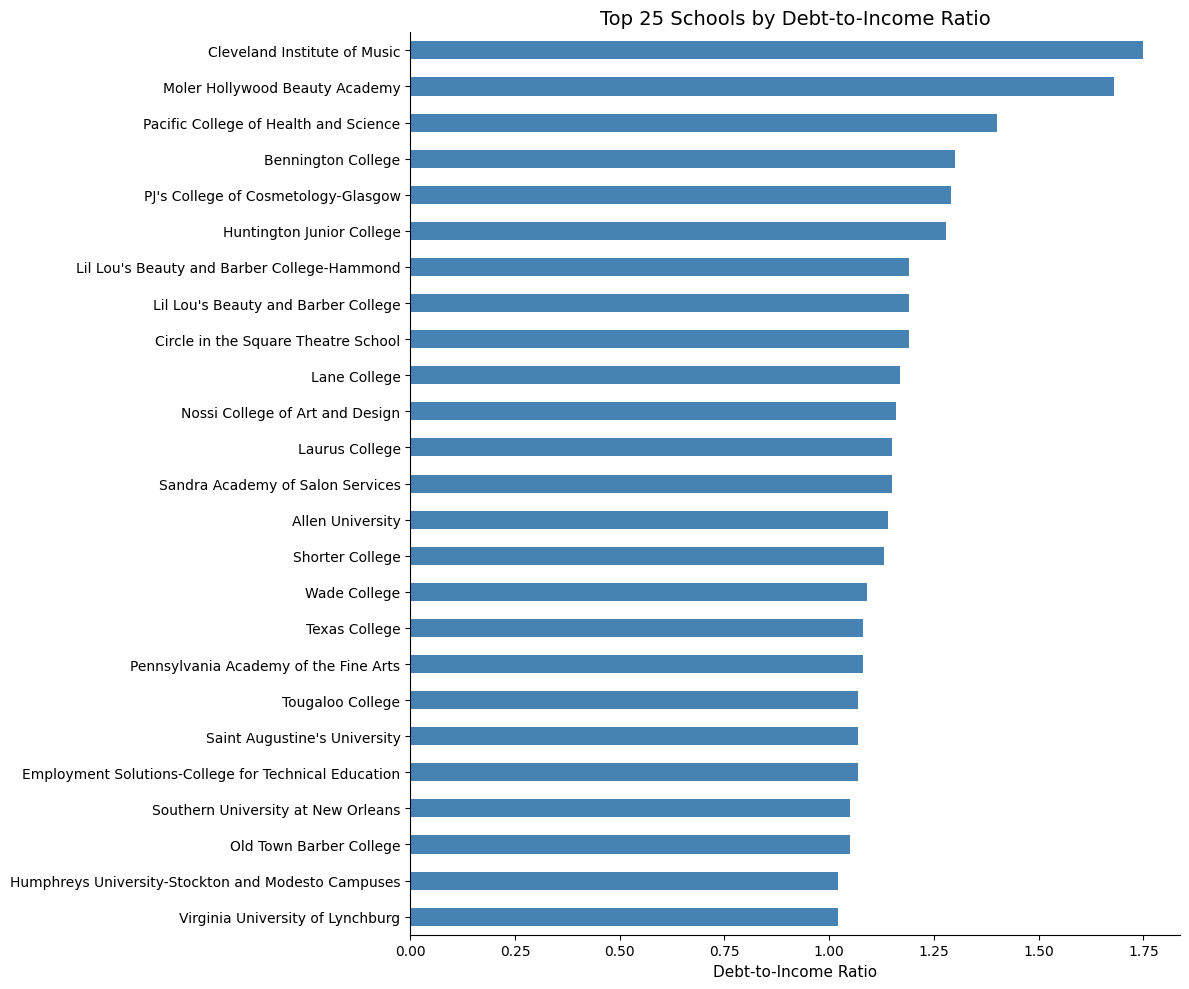

In [167]:


df_sorted = df_school_debt_limit_25.sort_values('debt_to_income_ratio', ascending=True)

df_sorted.plot(
    kind='barh',
    x='school_name',
    y='debt_to_income_ratio',
    figsize=(12, 10),
    color='steelblue',
    legend=False
)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.title('Top 25 Schools by Debt-to-Income Ratio', fontsize=14)
plt.xlabel('Debt-to-Income Ratio', fontsize=11)
plt.ylabel('')
plt.tight_layout()
plt.show()

### I intentionally created the same query as above to display school type vs debt to income ratio but increased the school count to 1000. This will create a more compelling scatter plot as seen below. The chart below clearly shows that public school is the most cost effective way to achieve a degree and minimize debt. Private school has the lowest debt but also the lowest earnings. Private Non-Profit schools seem to be the worst option with the some of the highest debt to income ratios of all the schools.

In [168]:
df_school_debt_1000 = pd.read_sql('''
    select i.school_name,
           i.state,
           case i.control_type
               when 1 THEN 'Public'
               when 2 THEN 'Private Non-Profit'
               when 3 THEN 'Private For-Profit'
                end AS school_type,
           count(*) AS program_count,
           round(avg(p.median_debt_stafford_grad_plus), 0) AS avg_debt,
           round(avg(p.median_earn_wne_5yr), 0) AS avg_earn_5yr,
           round(avg(p.median_debt_stafford_grad_plus)/ avg(p.median_earn_wne_5yr), 2) AS debt_to_income_ratio
    from programs p
    join institutions i 
        on p.school_id = i.school_id
    where p.median_earn_wne_4yr is not null
            and p.median_debt_stafford_grad_plus is not null
            and p.median_earn_wne_5yr > 0
    group by 
        i.school_id
        , i.school_name
        , i.state
        , i.control_type
    order by debt_to_income_ratio DESC
    limit 1000
''', connection)
display(df_school_debt_1000)

,school_name,state,school_type,program_count,avg_debt,avg_earn_5yr,debt_to_income_ratio
0,Cleveland Institute of Music,OH,Private Non-Profit,1,25500.0,14612.0,1.75
1,Moler Hollywood Beauty Academy,OH,Private For-Profit,1,20197.0,12046.0,1.68
2,Pacific College of Health and Science,NY,Private For-Profit,1,26712.0,19111.0,1.40
3,Bennington College,VT,Private Non-Profit,1,27000.0,20724.0,1.30
4,PJ's College of Cosmetology-Glasgow,KY,Private For-Profit,1,16500.0,12749.0,1.29
...,...,...,...,...,...,...,...
995,Tricoci University of Beauty Culture-Indianapolis,IN,Private For-Profit,1,11944.0,24660.0,0.48
996,Ottawa University-Milwaukee,WI,Private Non-Profit,1,27000.0,56507.0,0.48
997,Kenneth Shuler School of Cosmetology-Rock Hill,SC,Private For-Profit,1,10429.0,21821.0,0.48
998,Gwinnett College,NC,Private For-Profit,2,14009.0,29485.0,0.48


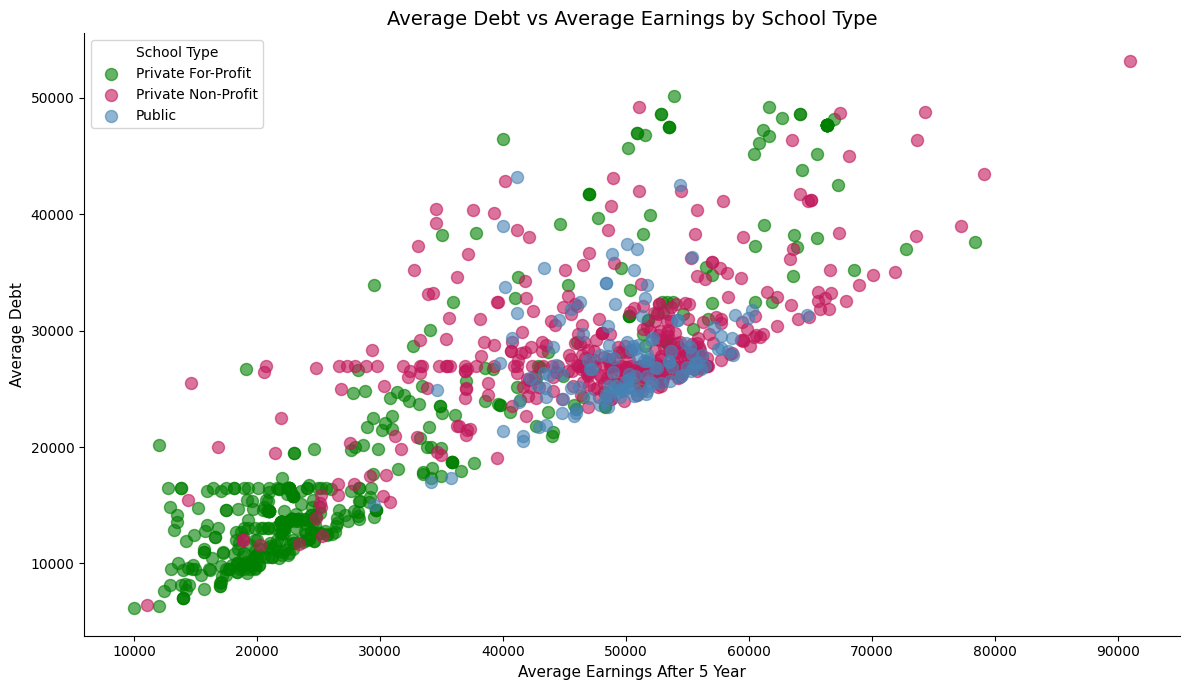

In [169]:


colors = {'Public': 'steelblue', 'Private Non-Profit': '#C2185B', 'Private For-Profit': 'green'}

fig, ax = plt.subplots(figsize=(12, 7))

for school_type, group in df_school_debt_1000.groupby('school_type'):
    ax.scatter(
        group['avg_earn_5yr'],
        group['avg_debt'],
        label=school_type,
        color=colors[school_type],
        alpha=0.6,
        s=75
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.title('Average Debt vs Average Earnings by School Type', fontsize=14)
plt.xlabel('Average Earnings After 5 Year', fontsize=11)
plt.ylabel('Average Debt', fontsize=11)
plt.legend(title='School Type')
plt.tight_layout()
plt.show()

### This sql query is designed to show which schools win the most awards and the percentage that wins by gender.

In [170]:
df_awards = pd.read_sql('''
    select i.school_name,
           i.state,
           sum(completions_total) as total_awards_all,
           sum(completions_female) as total_awards_female,
           sum(completions_male) as total_awards_male,
           round(cast(sum(completions_male) AS REAL)/sum(completions_total) * 100, 1) AS pct_male,
           round(cast(sum(completions_female) AS REAL) / sum(completions_total) * 100, 1) AS pct_female
    from awards a
    join institutions i 
        on a.school_id = i.school_id
    group by 
        i.school_id
        , i.school_name
    limit 1000
''', connection)
display(df_awards)

,school_name,state,total_awards_all,total_awards_female,total_awards_male,pct_male,pct_female
0,Alabama A & M University,AL,1662,1108,554,33.3,66.7
1,University of Alabama at Birmingham,AL,13438,8538,4900,36.5,63.5
2,Amridge University,AL,380,214,166,43.7,56.3
3,University of Alabama in Huntsville,AL,4360,1994,2366,54.3,45.7
4,Alabama State University,AL,1334,928,406,30.4,69.6
...,...,...,...,...,...,...,...
995,Mid-America College of Funeral Service,IN,204,132,72,35.3,64.7
996,West Michigan College of Barbering and Beauty,MI,52,24,28,53.8,46.2
997,University of Notre Dame,IN,8050,3700,4350,54.0,46.0
998,Oakland City University,IN,494,238,256,51.8,48.2


### I used the sum function to determine if women or men win more awards. Wow women win significantly more awards!!!

In [171]:
print(df_awards['total_awards_female'].sum())

2081358


In [172]:
print(df_awards['total_awards_male'].sum())

1462878


### This function is designed to display program salaries earned by students who receive a pell grant and those who don't. It also displays the earning gap.

In [173]:
def get_earnings_gap_pell_grant(program):

    query_pell_gap = f'''
            select program_name,
                round(avg(median_earn_pell_wne_4yr), 0) as avg_earn_pell,
                round(avg(median_earn_nopell_wne_4yr), 0) as avg_earn_nopell,
                round(avg(median_earn_nopell_wne_4yr) - avg(median_earn_pell_wne_4yr), 0) as pell_gap
            from programs
            where program_name like '%{program}%'and median_earn_pell_wne_4yr is not null and median_earn_nopell_wne_4yr is not null
            group by program_name, cred_label
            order by pell_gap desc
            '''
    return pd.read_sql(query_pell_gap, connection)


In [174]:
display(get_earnings_gap_pell_grant('Business'))

,program_name,avg_earn_pell,avg_earn_nopell,pell_gap
0,"Business, Management, Marketing, and Related S...",94840.0,129454.0,34614.0
1,"Business Administration, Management and Operat...",65185.0,87860.0,22675.0
2,Agricultural Business and Management.,49768.0,72392.0,22624.0
3,"Business Administration, Management and Operat...",52721.0,69210.0,16489.0
4,International Business.,80057.0,93653.0,13596.0
5,Entrepreneurial and Small Business Operations.,54140.0,66691.0,12551.0
6,"Business, Management, Marketing, and Related S...",34263.0,46789.0,12526.0
7,"Business/Commerce, General.",56518.0,67967.0,11449.0
8,Business/Corporate Communications.,46972.0,58319.0,11348.0
9,International Business.,54258.0,64522.0,10264.0


### Technical majors generally show the largest earnings gaps between students who received Pell Grants and those who did not.

In [175]:
df_pell = pd.read_sql('''
            select program_name,
                round(avg(median_earn_pell_wne_4yr), 0) as avg_earn_pell,
                round(avg(median_earn_nopell_wne_4yr), 0) as avg_earn_nopell,
                round(avg(median_earn_nopell_wne_4yr) - avg(median_earn_pell_wne_4yr), 0) as pell_gap
            from programs
            where  median_earn_pell_wne_4yr is not null and median_earn_nopell_wne_4yr is not null
            group by program_name, cred_label
            order by pell_gap desc
            limit 10
            '''
    , connection)
display(df_pell)

,program_name,avg_earn_pell,avg_earn_nopell,pell_gap
0,"Computer and Information Sciences, General.",109553.0,160355.0,50802.0
1,Human Resources Management and Services.,71015.0,121649.0,50634.0
2,"General Sales, Merchandising and Related Marke...",83275.0,124943.0,41668.0
3,Chemistry.,80557.0,122067.0,41510.0
4,"Legal Professions and Studies, Other.",59285.0,97566.0,38281.0
5,"Business, Management, Marketing, and Related S...",94840.0,129454.0,34614.0
6,Alternative and Complementary Medicine and Med...,32315.0,63639.0,31324.0
7,Physical Science Technologies/Technicians.,90334.0,119328.0,28994.0
8,Human Computer Interaction.,93262.0,122243.0,28981.0
9,"Computer and Information Sciences, General.",57806.0,83987.0,26181.0


In [176]:
df_awards = pd.read_sql('''  select * from awards''', connection)
display(df_awards)

,award_id,school_id,cip_code,cred_level,award_level,completions_total,completions_male,completions_female
0,1,100654,1.0999,None,5,12,2,10
1,2,100654,1.1001,None,5,10,1,9
2,3,100654,1.1001,None,7,7,1,6
3,4,100654,1.1001,None,17,6,3,3
4,5,100654,1.9999,None,5,2,1,1
...,...,...,...,...,...,...,...,...
286974,286975,500555,12.0402,None,2,15,12,3
286975,286976,500555,12.0409,None,2,15,1,14
286976,286977,500555,12.041,None,2,0,0,0
286977,286978,500555,12.0413,None,2,4,1,3


### This function is designed to show which schools (and degrees) will help you earn the highest salary

In [177]:
def get_top_earnings_by_schools_and_degree_by_state(state, limit=5):
    query = f'''
        select i.school_name,
               i.state,
               case i.control_type
                   when 1 then 'Public'
                   when 2 then 'Private Non-Profit'
                   when 3 then 'Private For-Profit'
               end as school_type,
               p.program_name,
               round(avg(p.median_earn_wne_5yr), 0) as avg_earn_5yr,
               round(avg(p.median_debt_stafford_grad_plus), 0) as avg_debt
        from programs p
        join institutions i on p.school_id = i.school_id
        where i.state = '{state}' and p.median_earn_wne_5yr is not null
        group by i.school_id, i.school_name, i.state, i.control_type, p.program_name
        order by avg_earn_5yr desc
        limit {limit}
    '''
    return pd.read_sql(query, connection)

In [178]:
get_top_earnings_by_schools_and_degree_by_state('KY',25)

,school_name,state,school_type,program_name,avg_earn_5yr,avg_debt
0,University of Pikeville,KY,Private Non-Profit,Medicine.,273309.0,NaN
1,University of Louisville,KY,Public,Advanced/Graduate Dentistry and Oral Sciences.,222062.0,NaN
2,University of Kentucky,KY,Public,Medicine.,191366.0,NaN
3,University of Kentucky,KY,Public,Dentistry.,185046.0,NaN
4,University of Louisville,KY,Public,Medicine.,184775.0,NaN
5,University of Louisville,KY,Public,Dentistry.,169952.0,NaN
6,Sullivan University,KY,Private For-Profit,"Pharmacy, Pharmaceutical Sciences, and Adminis...",143881.0,NaN
7,University of Kentucky,KY,Public,"Pharmacy, Pharmaceutical Sciences, and Adminis...",135815.0,NaN
8,Frontier Nursing University,KY,Private Non-Profit,"Registered Nursing, Nursing Administration, Nu...",121678.0,NaN
9,University of Kentucky,KY,Public,"Allied Health Diagnostic, Intervention, and Tr...",119533.0,NaN


### This function shows he user how much people earn by gender. You can type in a program name for example Business. Then, you see the pay amounts and the biggest pay gap between genders for that program.

In [179]:
def get_earnings_by_gender(program_name):
    query = f'''
        select program_name,
               cred_label,
               round(avg(median_earn_male_wne_4yr), 1) as avg_earnings_male,
               round(avg(median_earn_female_wne_4yr), 0) AS avg_earnings_female,
               round(avg(median_earn_male_wne_4yr) - avg(median_earn_female_wne_4yr), 0) AS earnings_gap
        from programs
        where program_name LIKE '%{program_name}%'
        group by program_name, cred_label
        order by earnings_gap desc
        limit 25
        '''
    return pd.read_sql(query, connection)
display(get_earnings_by_gender('Business'))

,program_name,cred_label,avg_earnings_male,avg_earnings_female,earnings_gap
0,Entrepreneurial and Small Business Operations.,Master's Degree,190128.0,114635.0,75493.0
1,Agricultural Business and Management.,Undergraduate Certificate or Diploma,38338.0,11137.0,27201.0
2,"Business Administration, Management and Operat...",Graduate/Professional Certificate,86091.5,62605.0,23487.0
3,"Business Administration, Management and Operat...",First Professional Degree,159267.3,138344.0,20923.0
4,"Business, Management, Marketing, and Related S...",Master's Degree,100477.4,79674.0,20803.0
5,"Business/Commerce, General.",Doctoral Degree,115573.0,98120.0,17453.0
6,International Business.,Undergraduate Certificate or Diploma,81088.0,63978.0,17110.0
7,"Business Administration, Management and Operat...",Master's Degree,99569.8,84161.0,15409.0
8,Agricultural Business and Management.,Associate's Degree,49416.5,34042.0,15375.0
9,International Business.,Master's Degree,88200.3,75369.0,12832.0


### I used Claude AI to help me build the data dictionary below and include a relevant description.  AI helped me to build this quickly so that I could organize it into a dataframe that could easily be displayed to the user. AI also helped me quickly search the College Scorecard site and the National Center for Education Statistics site to quickly get the correct definition for each field. I think a data dictionary is really important for this project in order to understand what all the fields represent.

### The python script transposes the data (flips the columns and rows) to make the data dictionary look cleaner, then assigns column names and displays the dictionary.

In [180]:
data_dictionary = {
    'school_id': {
        'original': 'UNITID',
        'table': 'institutions',
        'type': 'integer',
        'description': 'Unique identifier for each institution assigned by the U.S. Department of Education',
        'source': 'College Scorecard'
    },
    'school_name': {
        'original': 'INSTNM',
        'table': 'institutions',
        'type': 'text',
        'description': 'Name of the institution',
        'source': 'College Scorecard'
    },
    'state': {
        'original': 'STABBR',
        'table': 'institutions',
        'type': 'text',
        'description': 'State where the institution is located',
        'source': 'College Scorecard'
    },
    'region_code': {
        'original': 'REGION',
        'table': 'institutions',
        'type': 'integer',
        'description': 'Region code (1=New England, 2=Mid East, 3=Great Lakes, 4=Plains, 5=Southeast, 6=Southwest, 7=Rocky Mountains, 8=Far West, 9=Outlying Areas)',
        'source': 'College Scorecard'
    },
    'control_type': {
        'original': 'CONTROL',
        'table': 'institutions',
        'type': 'integer',
        'description': 'Control type (1=Public, 2=Private Non-Profit, 3=Private For-Profit)',
        'source': 'College Scorecard'
    },
    'predominant_degree': {
        'original': 'PREDDEG',
        'table': 'institutions',
        'type': 'integer',
        'description': 'Predominant degree awarded (0=Not classified, 1=Certificate, 2=Associate, 3=Bachelor\'s, 4=Graduate)',
        'source': 'College Scorecard'
    },
    'locale_type': {
        'original': 'LOCALE',
        'table': 'institutions',
        'type': 'integer',
        'description': 'Locale of institution (11-13=City, 21-23=Suburb, 31-33=Town, 41-43=Rural)',
        'source': 'College Scorecard'
    },
    'undergrad_enrollment': {
        'original': 'UGDS',
        'table': 'institutions',
        'type': 'real',
        'description': 'Total undergraduate enrollment',
        'source': 'College Scorecard'
    },
    'undergrad_men': {
        'original': 'UGDS_MEN',
        'table': 'institutions',
        'type': 'real',
        'description': 'Share of undergraduate students who are male',
        'source': 'College Scorecard'
    },
    'undergrad_women': {
        'original': 'UGDS_WOMEN',
        'table': 'institutions',
        'type': 'real',
        'description': 'Share of undergraduate students who are female',
        'source': 'College Scorecard'
    },
    'pct_pell_recipients': {
        'original': 'PCTPELL',
        'table': 'institutions',
        'type': 'real',
        'description': 'Share of undergraduates who received a Pell Grant',
        'source': 'College Scorecard'
    },
    'median_family_income': {
        'original': 'FAMINC',
        'table': 'institutions',
        'type': 'real',
        'description': 'Median family income of students in dollars',
        'source': 'College Scorecard'
    },
    'tuition_in_state': {
        'original': 'TUITIONFEE_IN',
        'table': 'institutions',
        'type': 'real',
        'description': 'In-state tuition and fees in dollars',
        'source': 'College Scorecard'
    },
    'tuition_out_of_state': {
        'original': 'TUITIONFEE_OUT',
        'table': 'institutions',
        'type': 'real',
        'description': 'Out-of-state tuition and fees in dollars',
        'source': 'College Scorecard'
    },
    'net_price_titleiv_public': {
        'original': 'NPT4_PUB',
        'table': 'institutions',
        'type': 'real',
        'description': 'Average net price for Title IV federal aid recipients at public institutions in dollars. Net price = cost of attendance minus grants and scholarships',
        'source': 'College Scorecard'
    },
    'net_price_titleiv_private': {
        'original': 'NPT4_PRIV',
        'table': 'institutions',
        'type': 'real',
        'description': 'Average net price for Title IV federal aid recipients at private institutions in dollars. Net price = cost of attendance minus grants and scholarships',
        'source': 'College Scorecard'
    },
    'avg_total_cost': {
        'original': 'COSTT4_A',
        'table': 'institutions',
        'type': 'real',
        'description': 'Average total cost of attendance for all students including tuition, fees, books, housing, and living expenses in dollars',
        'source': 'College Scorecard'
    },
    'completion_rate_150pct_4yr': {
        'original': 'C150_4',
        'table': 'institutions',
        'type': 'real',
        'description': 'Completion rate for first-time full-time students at 4-year institutions within 150% of expected time (e.g. finishing a 4-year degree within 6 years)',
        'source': 'College Scorecard'
    },
    'median_earn_wne_6yr': {
        'original': 'MD_EARN_WNE_P6',
        'table': 'institutions',
        'type': 'real',
        'description': 'Median earnings of students who are working and not enrolled (WNE) 6 years after initial entry. ',
        'source': 'College Scorecard'
    },
    'median_earn_wne_10yr': {
        'original': 'MD_EARN_WNE_P10',
        'table': 'institutions',
        'type': 'real',
        'description': 'Median earnings of students who are working and not enrolled (WNE) 10 years after initial entry.',
        'source': 'College Scorecard'
    },
    'median_debt': {
        'original': 'DEBT_MDN',
        'table': 'institutions',
        'type': 'real',
        'description': 'Median total debt at graduation for all students in dollars',
        'source': 'College Scorecard'
    },
    'cip_code': {
        'original': 'CIPCODE',
        'table': 'programs',
        'type': 'text',
        'description': 'Classification of Instructional Programs code is a 4-digit code identifying the field of study',
        'source': 'College Scorecard'
    },
    'program_name': {
        'original': 'CIPDESC',
        'table': 'programs',
        'type': 'text',
        'description': 'Field of study (e.g. Computer Science)',
        'source': 'College Scorecard'
    },
    'cred_level': {
        'original': 'CREDLEV',
        'table': 'programs',
        'type': 'integer',
        'description': 'Credential level code (1=Certificate, 2=Associate\'s, 3=Bachelor\'s, 4=Post-Bacc Certificate, 5=Master\'s, 6=Doctoral, 7=First Professional, 8=Post-Master\'s Certificate)',
        'source': 'College Scorecard'
    },
    'cred_label': {
        'original': 'CREDDESC',
        'table': 'programs',
        'type': 'text',
        'description': 'Credential level (e.g. Bachelor\'s Degree, Associate\'s Degree)',
        'source': 'College Scorecard'
    },
    'median_debt_stafford_grad_plus': {
        'original': 'DEBT_ALL_STGP_ANY_MDN',
        'table': 'programs',
        'type': 'real',
        'description': 'Median federal loan debt for all students in dollars. STGP = Stafford and Graduate PLUS loans (Direct Subsidized, Unsubsidized, and Grad PLUS). ANY = loans at any institution attended.',
        'source': 'College Scorecard'
    },
    'median_debt_male_stafford_grad_plus': {
        'original': 'DEBT_MALE_STGP_ANY_MDN',
        'table': 'programs',
        'type': 'real',
        'description': 'Median  Stafford and Graduate PLUS loan debt for male students in dollars',
        'source': 'College Scorecard'
    },
    'median_debt_female_stafford_grad_plus': {
        'original': 'DEBT_NOTMALE_STGP_ANY_MDN',
        'table': 'programs',
        'type': 'real',
        'description': 'Median Stafford and Graduate PLUS loan debt for female students in dollars.',
        'source': 'College Scorecard'
    },
    'median_earn_wne_1yr': {
        'original': 'EARN_MDN_1YR',
        'table': 'programs',
        'type': 'real',
        'description': 'Median earnings of all students working and not enrolled (WNE) 1 year after completion. WNE excludes students who returned to school or had no earnings.',
        'source': 'College Scorecard'
    },
    'median_earn_wne_4yr': {
        'original': 'EARN_MDN_4YR',
        'table': 'programs',
        'type': 'real',
        'description': 'Median earnings of all students working and not enrolled (WNE) 4 years after completion. WNE excludes students who returned to school or had no earnings.',
        'source': 'College Scorecard'
    },
    'median_earn_wne_5yr': {
        'original': 'EARN_MDN_5YR',
        'table': 'programs',
        'type': 'real',
        'description': 'Median earnings of all students working and not enrolled (WNE) 5 years after completion. WNE excludes students who returned to school or had no earnings.',
        'source': 'College Scorecard'
    },
    'median_earn_male_wne_1yr': {
        'original': 'EARN_MALE_WNE_MDN_1YR',
        'table': 'programs',
        'type': 'real',
        'description': 'Median earnings of male students working and not enrolled (WNE) 1 year after completion',
        'source': 'College Scorecard'
    },
    'median_earn_male_wne_4yr': {
        'original': 'EARN_MALE_WNE_MDN_4YR',
        'table': 'programs',
        'type': 'real',
        'description': 'Median earnings of male students working and not enrolled (WNE) 4 years after completion',
        'source': 'College Scorecard'
    },
    'median_earn_female_wne_1yr': {
        'original': 'EARN_NOMALE_WNE_MDN_1YR',
        'table': 'programs',
        'type': 'real',
        'description': 'Median earnings of female students working and not enrolled (WNE) 1 year after completion.',
        'source': 'College Scorecard'
    },
    'median_earn_female_wne_4yr': {
        'original': 'EARN_NOMALE_WNE_MDN_4YR',
        'table': 'programs',
        'type': 'real',
        'description': 'Median earnings of female students working and not enrolled (WNE) 4 years after completion.',
        'source': 'College Scorecard'
    },
    'median_earn_pell_wne_1yr': {
        'original': 'EARN_PELL_WNE_MDN_1YR',
        'table': 'programs',
        'type': 'real',
        'description': 'Median earnings of Pell Grant recipients working and not enrolled (WNE) 1 year after completion. Pell Grants are need-based federal grants for low-income students',
        'source': 'College Scorecard'
    },
    'median_earn_nopell_wne_1yr': {
        'original': 'EARN_NOPELL_WNE_MDN_1YR',
        'table': 'programs',
        'type': 'real',
        'description': 'Median earnings of non-Pell Grant students working and not enrolled (WNE) 1 year after completion',
        'source': 'College Scorecard'
    },
    'median_earn_pell_wne_4yr': {
        'original': 'EARN_PELL_WNE_MDN_4YR',
        'table': 'programs',
        'type': 'real',
        'description': 'Median earnings of Pell Grant recipients working and not enrolled (WNE) 4 years after completion',
        'source': 'College Scorecard'
    },
    'median_earn_nopell_wne_4yr': {
        'original': 'EARN_NOPELL_WNE_MDN_4YR',
        'table': 'programs',
        'type': 'real',
        'description': 'Median earnings of non-Pell Grant students working and not enrolled (WNE) 4 years after completion',
        'source': 'College Scorecard'
    },
    'award_level': {
        'original': 'AWLEVEL',
        'table': 'awards',
        'type': 'integer',
        'description': 'Award Code (1=1 year cert, 2=2 year cert, 3=Associate\'s, 4=2-4yr cert, 5=Bachelor\'s, 6=Post-bacc cert, 7=Master\'s, 8=Post-master\'s cert, 17=Doctor Research, 18=Doctor Professional, 21=First Professional)',
        'source': 'IPEDS C2024A'
    },
    'completions_total': {
        'original': 'CTOTALT',
        'table': 'awards',
        'type': 'integer',
        'description': 'Total number of awards (awards/degrees given) ',
        'source': 'IPEDS C2024A'
    },
    'completions_male': {
        'original': 'CTOTALM',
        'table': 'awards',
        'type': 'integer',
        'description': 'Total number of awards (degrees, etc.) for male students',
        'source': 'IPEDS C2024A'
    },
    'completions_female': {
        'original': 'CTOTALW',
        'table': 'awards',
        'type': 'integer',
        'description': 'Total number of awards (degrees, etc.) for female students',
    },
}

df_data_dict = pd.DataFrame(data_dictionary).T.reset_index()
df_data_dict.columns = ['field_name', 'original', 'table', 'type', 'description', 'source']
display(df_data_dict)

,field_name,original,table,type,description,source
0,school_id,UNITID,institutions,integer,Unique identifier for each institution assigne...,College Scorecard
1,school_name,INSTNM,institutions,text,Name of the institution,College Scorecard
2,state,STABBR,institutions,text,State where the institution is located,College Scorecard
3,region_code,REGION,institutions,integer,"Region code (1=New England, 2=Mid East, 3=Grea...",College Scorecard
4,control_type,CONTROL,institutions,integer,"Control type (1=Public, 2=Private Non-Profit, ...",College Scorecard
5,predominant_degree,PREDDEG,institutions,integer,"Predominant degree awarded (0=Not classified, ...",College Scorecard
6,locale_type,LOCALE,institutions,integer,"Locale of institution (11-13=City, 21-23=Subur...",College Scorecard
7,undergrad_enrollment,UGDS,institutions,real,Total undergraduate enrollment,College Scorecard
8,undergrad_men,UGDS_MEN,institutions,real,Share of undergraduate students who are male,College Scorecard
9,undergrad_women,UGDS_WOMEN,institutions,real,Share of undergraduate students who are female,College Scorecard
